In [104]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror{font-family:Consolas; font-size:15pt;}
div.output{font-size:12pt; font-weight:bold;}
div.input{font-family:Consolas; font-size:12pt;}
div.prompt{min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

## 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 가져옴

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 훈련셋과 테스트셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화
# quiz에서는 scale조정, train_test_split 등을 추가

In [4]:
import numpy as np
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [8]:
print('타겟 :', data[0,0])
# print('이미지(28*28을 1차원으로) :', data[0, 1:].reshape(28,28))

타겟 : 5.0


In [9]:
for row in data[0, 1:].reshape(28,28):
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

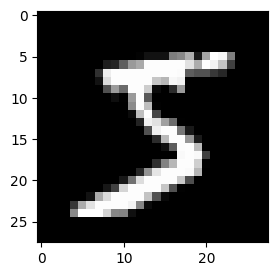

In [12]:
plt.figure(figsize=(3,3))
plt.imshow(data[0, 1:].reshape(28,28), cmap='gray')

In [18]:
%pip install opencv-contrib-python

   ---------------------------------------- 0.0/46.2 MB ? eta -:--:--
   -- ------------------------------------- 2.4/46.2 MB 11.2 MB/s eta 0:00:04
   --- ------------------------------------ 4.2/46.2 MB 11.4 MB/s eta 0:00:04
   --- ------------------------------------ 4.2/46.2 MB 11.4 MB/s eta 0:00:04
   ----- ---------------------------------- 6.8/46.2 MB 7.8 MB/s eta 0:00:06
   ------- -------------------------------- 9.2/46.2 MB 8.6 MB/s eta 0:00:05
   --------- ------------------------------ 10.7/46.2 MB 8.3 MB/s eta 0:00:05
   ----------- ---------------------------- 13.4/46.2 MB 8.8 MB/s eta 0:00:04
   ------------- -------------------------- 15.7/46.2 MB 9.2 MB/s eta 0:00:04
   --------------- ------------------------ 17.6/46.2 MB 9.1 MB/s eta 0:00:04
   ---------------- ----------------------- 18.9/46.2 MB 8.8 MB/s eta 0:00:04
   ----------------- ---------------------- 20.7/46.2 MB 8.7 MB/s eta 0:00:03
   ------------------- -------------------- 22.8/46.2 MB 8.8 MB/s eta 0:00

In [20]:
%pip install opencv-python

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   -- ------------------------------------- 2.4/39.5 MB 11.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.7/39.5 MB 11.4 MB/s eta 0:00:04
   ------- -------------------------------- 7.3/39.5 MB 11.6 MB/s eta 0:00:03
   --------- ------------------------------ 9.7/39.5 MB 11.6 MB/s eta 0:00:03
   ------------ --------------------------- 12.3/39.5 MB 11.7 MB/s eta 0:00:03
   -------------- ------------------------- 14.7/39.5 MB 11.5 MB/s eta 0:00:03
   ---------------- ----------------------- 16.5/39.5 MB 11.3 MB/s eta 0:00:03
   ------------------ --------------------- 18.6/39.5 MB 11.0 MB/s eta 0:00:02
   -------------------- ------------------- 20.2/39.5 MB 10.7 MB/s eta 0:00:02
   ---------------------- ----------------- 22.3/39.5 MB 10.7 MB/s eta 0:00:02
   ------------------------ --------------- 24.6/39.5 MB 10.7 MB/s eta 0:00:02
   --------------------------- ------------ 26.7/39.5 MB 10.7 MB/

ERROR: Could not install packages due to an OSError: [WinError 5] 액세스가 거부되었습니다: 'C:\\Users\\Admin\\anaconda3\\envs\\ml-dl-nlp\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [23]:
# 칼라사진 -> 흑백모드의 넘파이 배열로
import cv2
image_gray = cv2.imread('data/img.jpg', cv2.IMREAD_GRAYSCALE) # 흑백포맷으로 읽기
print(type(image_gray))

<class 'numpy.ndarray'>


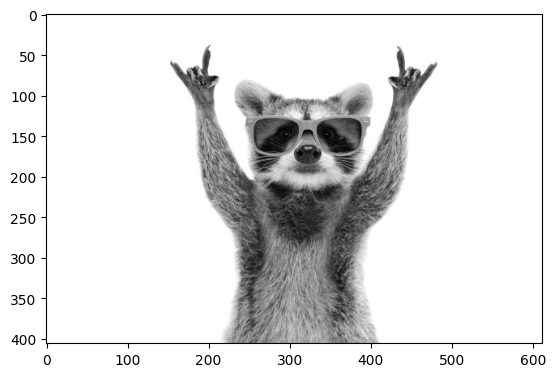

In [25]:
# plt.figure(figsize=(3,3))
plt.imshow(image_gray, cmap='gray')

# 1. 데이터 생성 및 전처리

In [50]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape
# 28*28사이즈의 넘파이배열?이 60000개

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [51]:
print(y_train[0])
for row in X_train[0]:
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

5
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0

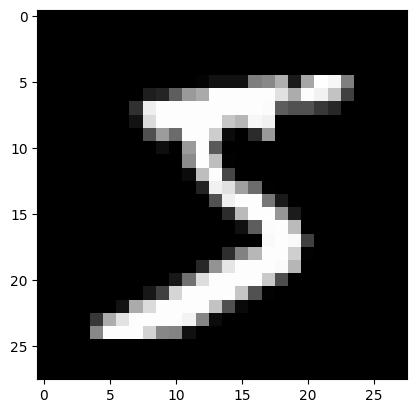

In [31]:
plt.imshow(X_train[0], cmap='gray')

In [32]:
# 학습셋(60000개) -> 훈련셋(50000개)+검증셋(10000개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [36]:
# 학습셋(5만개:fit용), 검증셋(만개:fit용), 테스트셋(만:평가용)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)
(10000, 28, 28) (10000,)


In [48]:
# 입력(독립)변수 (n,28,28) -> (n,784(1차원으로)) -> 실수형변환 -> 스케일조정(255.0으로 나누기)
# 255로 나누는 이유 : 0부터 255까지 범위가 똑같음(0부터 1까지만 있게 하려고)
train_X = X_train.reshape(50000, 784).astype(float)/255.0
val_X = X_val.reshape(10000, -1).astype(float)/255.0
test_X = X_test.reshape(10000, -1).astype(float)/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [53]:
# 훈련셋 5만개 -> 700개, 테스트셋 1만개 -> 300개 추출, 테스트셋은 그대로
# 데이터가 너무 많아서 학습시간을 줄이려고(fit시간 절약)
train_idx = np.random.choice(50000, 700)
val_idx = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X = val_X[val_idx]
y_val = y_val[val_idx]
train_X.shape, y_train.shape, val_X.shape, y_val.shape

((700, 784), (700,), (300, 784), (300,))

In [58]:
# 분류분석에서 타겟(종속)변수는 원핫인코딩해야함
train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
print(y_train[:2])
print(train_Y[:2])

[9 4]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [59]:
# 데이터 처리 전 작업
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(60000개) -> 훈련셋(50000개)+검증셋(10000개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype(float)/255.0
val_X = X_val.reshape(10000, -1).astype(float)/255.0
test_X = X_test.reshape(10000, -1).astype(float)/255.0
train_idx = np.random.choice(50000, 700)
val_idx = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X = val_X[val_idx]
y_val = y_val[val_idx]
# 분류분석에서 타겟(종속)변수는 원핫인코딩해야함
train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

In [ ]:
# 입력변수 갯수는 784개, 출력변수 갯수는 10개

# 2. 모델 구성

In [60]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu')) # 지금은 빨리맞추게 하려고 2, 잘알아맞추게 하려면 units를 높여야함
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 1570      
                                                                 
 dense_1 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 3. 학습과정 설정

In [61]:
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy(원핫인코딩을 안할경우 씀)
              optimizer='adam',
              metrics=['accuracy'])

# 4. 모델 학습

In [62]:
%%time
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y))

Epoch 1/500
7/7 [==============================] - 1s 32ms/step - loss: 2.3536 - accuracy: 0.1371 - val_loss: 2.2876 - val_accuracy: 0.1867
Epoch 2/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2757 - accuracy: 0.1714 - val_loss: 2.2471 - val_accuracy: 0.1967
Epoch 3/500
7/7 [==============================] - 0s 6ms/step - loss: 2.2417 - accuracy: 0.1743 - val_loss: 2.2240 - val_accuracy: 0.1667
Epoch 4/500
7/7 [==============================] - 0s 6ms/step - loss: 2.2214 - accuracy: 0.1686 - val_loss: 2.2044 - val_accuracy: 0.1733
Epoch 5/500
7/7 [==============================] - 0s 6ms/step - loss: 2.2012 - accuracy: 0.1743 - val_loss: 2.1834 - val_accuracy: 0.1833
Epoch 6/500
7/7 [==============================] - 0s 7ms/step - loss: 2.1800 - accuracy: 0.1857 - val_loss: 2.1600 - val_accuracy: 0.1967
Epoch 7/500
7/7 [==============================] - 0s 6ms/step - loss: 2.1570 - accuracy: 0.1957 - val_loss: 2.1344 - val_accuracy: 0.1967
Epoch 8/500
7/7 [=========

7/7 [==============================] - 0s 6ms/step - loss: 1.3318 - accuracy: 0.5100 - val_loss: 1.4404 - val_accuracy: 0.4333
Epoch 118/500
7/7 [==============================] - 0s 6ms/step - loss: 1.3286 - accuracy: 0.5143 - val_loss: 1.4380 - val_accuracy: 0.4300
Epoch 119/500
7/7 [==============================] - 0s 6ms/step - loss: 1.3258 - accuracy: 0.5143 - val_loss: 1.4358 - val_accuracy: 0.4367
Epoch 120/500
7/7 [==============================] - 0s 6ms/step - loss: 1.3228 - accuracy: 0.5129 - val_loss: 1.4362 - val_accuracy: 0.4267
Epoch 121/500
7/7 [==============================] - 0s 6ms/step - loss: 1.3203 - accuracy: 0.5200 - val_loss: 1.4328 - val_accuracy: 0.4333
Epoch 122/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3172 - accuracy: 0.5171 - val_loss: 1.4321 - val_accuracy: 0.4367
Epoch 123/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3145 - accuracy: 0.5186 - val_loss: 1.4299 - val_accuracy: 0.4467
Epoch 124/500
7/7 [========

7/7 [==============================] - 0s 6ms/step - loss: 1.0834 - accuracy: 0.6043 - val_loss: 1.3694 - val_accuracy: 0.5100
Epoch 234/500
7/7 [==============================] - 0s 6ms/step - loss: 1.0816 - accuracy: 0.6071 - val_loss: 1.3692 - val_accuracy: 0.5100
Epoch 235/500
7/7 [==============================] - 0s 6ms/step - loss: 1.0801 - accuracy: 0.6043 - val_loss: 1.3667 - val_accuracy: 0.5067
Epoch 236/500
7/7 [==============================] - 0s 6ms/step - loss: 1.0782 - accuracy: 0.6071 - val_loss: 1.3683 - val_accuracy: 0.5067
Epoch 237/500
7/7 [==============================] - 0s 6ms/step - loss: 1.0771 - accuracy: 0.6086 - val_loss: 1.3696 - val_accuracy: 0.5067
Epoch 238/500
7/7 [==============================] - 0s 6ms/step - loss: 1.0752 - accuracy: 0.6071 - val_loss: 1.3675 - val_accuracy: 0.5100
Epoch 239/500
7/7 [==============================] - 0s 6ms/step - loss: 1.0737 - accuracy: 0.6143 - val_loss: 1.3693 - val_accuracy: 0.5067
Epoch 240/500
7/7 [========

7/7 [==============================] - 0s 7ms/step - loss: 0.9364 - accuracy: 0.6529 - val_loss: 1.4228 - val_accuracy: 0.5067
Epoch 350/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9353 - accuracy: 0.6514 - val_loss: 1.4224 - val_accuracy: 0.5067
Epoch 351/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9340 - accuracy: 0.6514 - val_loss: 1.4256 - val_accuracy: 0.5100
Epoch 352/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9333 - accuracy: 0.6600 - val_loss: 1.4257 - val_accuracy: 0.5100
Epoch 353/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9334 - accuracy: 0.6500 - val_loss: 1.4233 - val_accuracy: 0.5067
Epoch 354/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9310 - accuracy: 0.6486 - val_loss: 1.4310 - val_accuracy: 0.5133
Epoch 355/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9304 - accuracy: 0.6600 - val_loss: 1.4293 - val_accuracy: 0.5067
Epoch 356/500
7/7 [========

7/7 [==============================] - 0s 6ms/step - loss: 0.8454 - accuracy: 0.6943 - val_loss: 1.5414 - val_accuracy: 0.4967
Epoch 466/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8447 - accuracy: 0.6900 - val_loss: 1.5415 - val_accuracy: 0.4967
Epoch 467/500
7/7 [==============================] - 0s 9ms/step - loss: 0.8444 - accuracy: 0.6900 - val_loss: 1.5424 - val_accuracy: 0.4967
Epoch 468/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8435 - accuracy: 0.6900 - val_loss: 1.5403 - val_accuracy: 0.4967
Epoch 469/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8432 - accuracy: 0.6900 - val_loss: 1.5457 - val_accuracy: 0.4967
Epoch 470/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8424 - accuracy: 0.6929 - val_loss: 1.5454 - val_accuracy: 0.5000
Epoch 471/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8417 - accuracy: 0.6914 - val_loss: 1.5447 - val_accuracy: 0.5000
Epoch 472/500
7/7 [========

# 5. 모델 평가하기

In [63]:
# 학습 과정 살펴보기
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

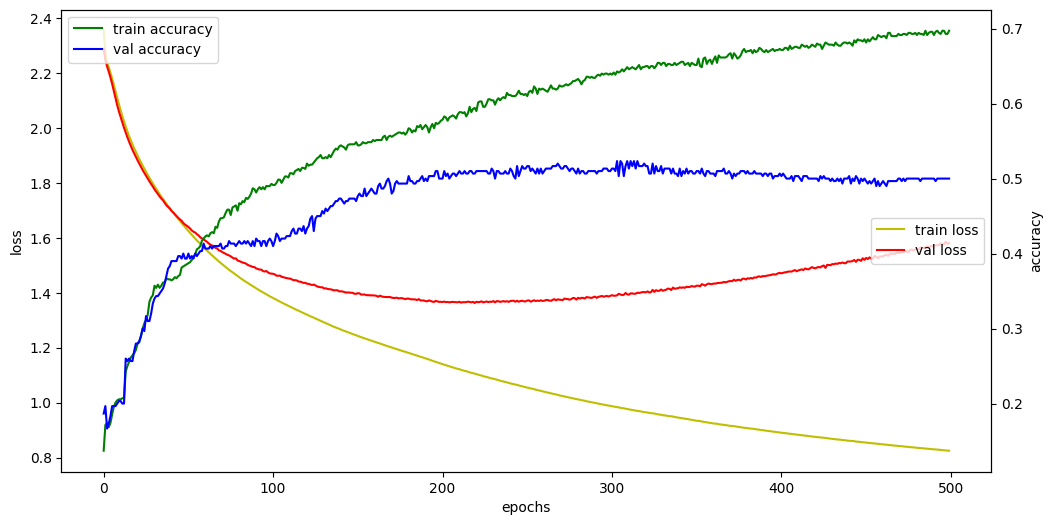

In [64]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [66]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

loss : 1.6654986143112183
accuracy : 0.4875999987125397


# 위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validation data추가, dropout, 활성화함수 relu계열, tanh)
- epoch 조정
- optimizer 변경

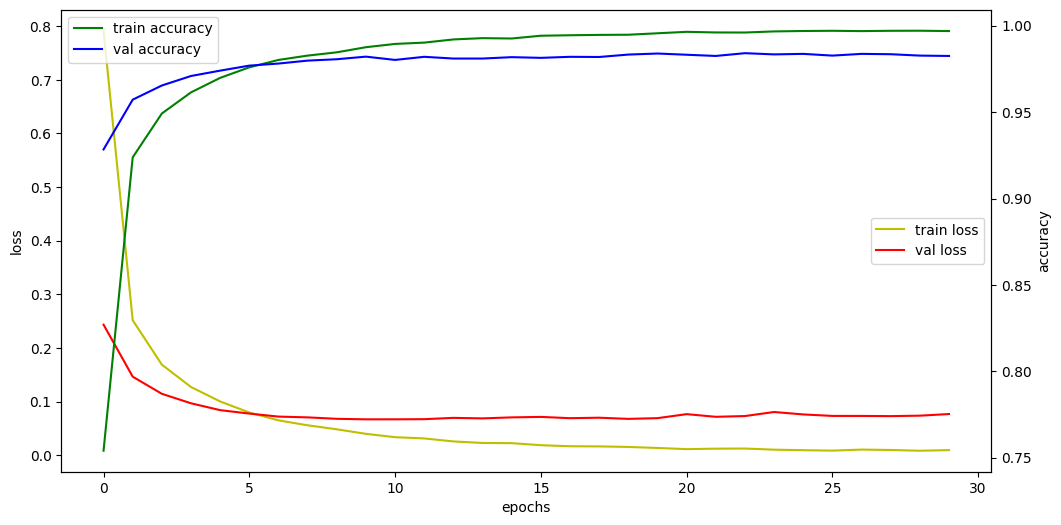

loss : 0.06994112581014633
accuracy : 0.9837999939918518
CPU times: total: 8min 40s
Wall time: 1min 32s


In [79]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000개 -> 700개, 10000개 -> 300개
# train_idx = np.random.choice(50000, 30000)
# val_idx  = np.random.choice(10000, 8000)
# train_X = train_X[train_idx]
# y_train = y_train[train_idx]
# val_X   = val_X[val_idx]
# y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1024, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))

model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])

hist = model.fit(train_X, train_Y,
                epochs=30,
                batch_size=2000,
                validation_data=(val_X, val_Y),
                verbose=0)

fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

In [80]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

loss : 0.06994112581014633
accuracy : 0.9837999939918518


In [81]:
test_Y # 원핫인코딩 하기 전이 실제값

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [83]:
# 실제값
test_Y.argmax(axis=1)
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [85]:
np.all(test_Y.argmax(axis=1) == y_test)

True

In [89]:
# 예측값
yhat = model.predict(test_X).argmax(axis=1)
yhat = np.argmax(model.predict(test_X), axis=1)
yhat

313/313 [==============================] - 1s 4ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [90]:
pd.crosstab(y_test, yhat) # 분류가 많을때

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,971,1,1,0,0,0,5,1,1,0
1,0,1128,1,1,0,1,2,1,1,0
2,5,1,1014,1,1,0,2,4,4,0
3,0,0,4,993,0,4,0,2,4,3
4,2,0,3,0,956,0,7,3,1,10
5,2,0,0,6,1,877,3,0,3,0
6,1,2,0,0,1,3,950,0,1,0
7,1,1,7,2,0,0,0,1010,3,4
8,0,0,2,3,2,3,1,2,957,4


In [92]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, yhat)

array([[ 971,    1,    1,    0,    0,    0,    5,    1,    1,    0],
       [   0, 1128,    1,    1,    0,    1,    2,    1,    1,    0],
       [   5,    1, 1014,    1,    1,    0,    2,    4,    4,    0],
       [   0,    0,    4,  993,    0,    4,    0,    2,    4,    3],
       [   2,    0,    3,    0,  956,    0,    7,    3,    1,   10],
       [   2,    0,    0,    6,    1,  877,    3,    0,    3,    0],
       [   1,    2,    0,    0,    1,    3,  950,    0,    1,    0],
       [   1,    1,    7,    2,    0,    0,    0, 1010,    3,    4],
       [   0,    0,    2,    3,    2,    3,    1,    2,  957,    4],
       [   3,    3,    0,    5,    7,    4,    1,    3,    1,  982]],
      dtype=int64)

In [94]:
# 틀린 갯수 : 
10000-10000*loss_and_metrics[1]

162.00006008148193

In [95]:
cnt = 0
for y, h in zip(y_test, yhat):
    if y!=h:
        cnt += 1
print('틀린 갯수 :', cnt)

틀린 갯수 : 162


In [96]:
model.save('model/08_mnist.h5')

# ※ 콜백함수1 : 로그 출력

In [97]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [99]:
%%time
# 매epoch마다 로그 출력하면 지저분해질 수 있으니, 특정 epoch마다 로그 출력하도록 제한
# 반드시 콜백함수한테 상속받아야함
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}): # 1 epoch마다 자동 실행되는 함수(내가 호출하지 않아도)
        self.epoch += 1 # epoch마다 self.epoch값을 1씩 증가
        if self.epoch%10 == 0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{}'.\
                  format(self.epoch,
                         logs.get('loss'),
                         logs.get('accuracy', '-'), # 없으면 - 나옴
                         logs.get('val_loss', '-'),
                         logs.get('val_accuracy', '-')
                        )
                 )

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000개 -> 700개, 10000개 -> 300개
train_idx = np.random.choice(50000, 30000)
val_idx  = np.random.choice(10000, 8000)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 학습
customHistory = CustomHistory() # fit하기전에 객체 생성
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=2000,
                validation_data=(val_X, val_Y),
                verbose=0,
                callbacks=[customHistory]) # 콜백함수(객체이름 넣어야함), 콜백함수 만들었으면 verbose는 0으로 해야함

epoch:10, loss:1.8550821542739868, acc:0.2909333407878876, val_loss:1.8308227062225342, val_acc:0.29074999690055847
epoch:20, loss:1.6279410123825073, acc:0.4130333364009857, val_loss:1.6076633930206299, val_acc:0.4282500147819519
epoch:30, loss:1.4831616878509521, acc:0.49123331904411316, val_loss:1.4709019660949707, val_acc:0.49900001287460327
epoch:40, loss:1.4060553312301636, acc:0.5223333239555359, val_loss:1.397433876991272, val_acc:0.5298749804496765
epoch:50, loss:1.3543726205825806, acc:0.541266679763794, val_loss:1.3496986627578735, val_acc:0.5479999780654907
CPU times: total: 17.3 s
Wall time: 6.02 s


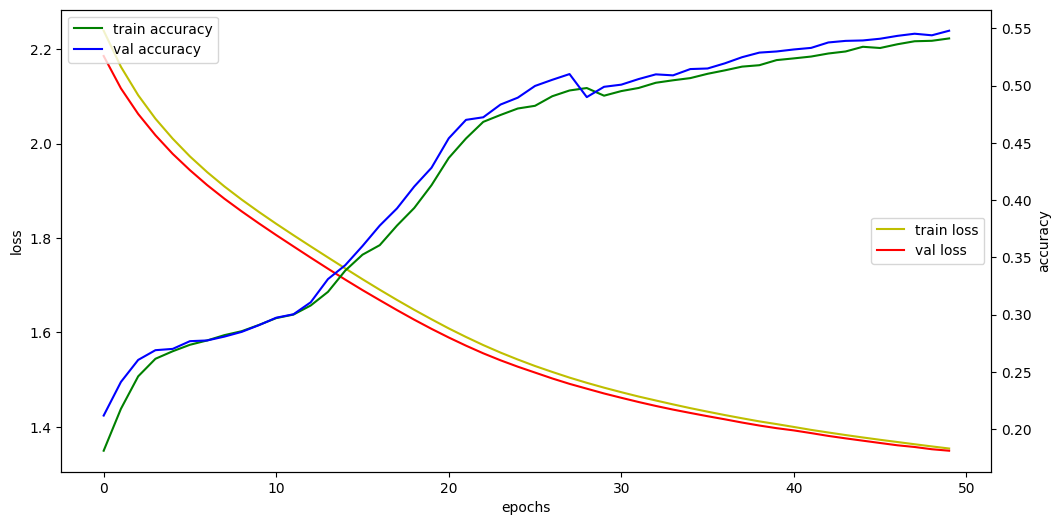

In [100]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

# ※ 콜백함수2 : EarlyStopping
- val_loss값이 줄어들어야 정상, 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 기준이면, 값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [102]:
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 학습
# 모니터를 안쓰면 val_loss 기준
# 모니터 기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=2) # 객체 생성
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping]) # 콜백함수

Epoch 1/500
300/300 [==============================] - 1s 2ms/step - loss: 1.9710 - accuracy: 0.2403 - val_loss: 1.7710 - val_accuracy: 0.3110
Epoch 2/500
300/300 [==============================] - 1s 2ms/step - loss: 1.6716 - accuracy: 0.3570 - val_loss: 1.5911 - val_accuracy: 0.4139
Epoch 3/500
300/300 [==============================] - 1s 2ms/step - loss: 1.5405 - accuracy: 0.4408 - val_loss: 1.4956 - val_accuracy: 0.4721
Epoch 4/500
300/300 [==============================] - 1s 2ms/step - loss: 1.4574 - accuracy: 0.4777 - val_loss: 1.4200 - val_accuracy: 0.4940
Epoch 5/500
300/300 [==============================] - 1s 2ms/step - loss: 1.3879 - accuracy: 0.4991 - val_loss: 1.3562 - val_accuracy: 0.5113
Epoch 6/500
300/300 [==============================] - 1s 2ms/step - loss: 1.3270 - accuracy: 0.5080 - val_loss: 1.2997 - val_accuracy: 0.5241
Epoch 7/500
300/300 [==============================] - 1s 2ms/step - loss: 1.2758 - accuracy: 0.5281 - val_loss: 1.2510 - val_accuracy: 0.5619

# ※ 콜백함수3 : ModelCheckpoint
- epoch마다 val_accuracy(val_loss, accuracy, loss)값이 좋을 때 모델을 자동 저장하는 콜백

In [103]:
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 학습
# 모니터를 안쓰면 val_loss 기준
# 모니터 기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=10) # 객체 생성
# 모델 자동 저장 콜백
# 객체 만들기 전 폴더 생성
# 파일이름 : ex) mnist-002-val0.1415.h5, mnist-005-val0.1912.h5 파일보고 더 좋을걸로 쓰면 됨
import os
model_save_folder = './model08/' # 뒤에 /(슬래시)해야함
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'
    
checkpoint = ModelCheckpoint(filepath=file, # 저장경로
                             monitor='val_accuracy', # 모니터 할 지표(기준)
                             save_best_only=True, # 모니터링 지표가 개선된 경우만 저장(좋아질때만)
                             mode='max', # 값이 클수록 저장
                             verbose=1 # 저장할 때 로그 출력
                             )

hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping, checkpoint]) # 콜백함수

Epoch 1/500
281/300 [===========================>..] - ETA: 0s - loss: 1.9645 - accuracy: 0.2494
Epoch 1: val_accuracy improved from -inf to 0.30263, saving model to ./model08\mnist-001-val0.3026.h5
300/300 [==============================] - 1s 3ms/step - loss: 1.9535 - accuracy: 0.2521 - val_loss: 1.7735 - val_accuracy: 0.3026
Epoch 2/500
277/300 [==========================>...] - ETA: 0s - loss: 1.6850 - accuracy: 0.3679
Epoch 2: val_accuracy improved from 0.30263 to 0.42400, saving model to ./model08\mnist-002-val0.4240.h5
300/300 [==============================] - 1s 2ms/step - loss: 1.6763 - accuracy: 0.3722 - val_loss: 1.5710 - val_accuracy: 0.4240
Epoch 3/500
299/300 [============================>.] - ETA: 0s - loss: 1.5045 - accuracy: 0.4389
Epoch 3: val_accuracy improved from 0.42400 to 0.45412, saving model to ./model08\mnist-003-val0.4541.h5
300/300 [==============================] - 1s 2ms/step - loss: 1.5046 - accuracy: 0.4390 - val_loss: 1.4347 - val_accuracy: 0.4541
Epoc

287/300 [===========================>..] - ETA: 0s - loss: 1.1385 - accuracy: 0.5918
Epoch 26: val_accuracy did not improve from 0.61200
300/300 [==============================] - 1s 2ms/step - loss: 1.1375 - accuracy: 0.5930 - val_loss: 1.1175 - val_accuracy: 0.6066
Epoch 27/500
294/300 [============================>.] - ETA: 0s - loss: 1.1343 - accuracy: 0.5963
Epoch 27: val_accuracy did not improve from 0.61200
300/300 [==============================] - 1s 2ms/step - loss: 1.1342 - accuracy: 0.5962 - val_loss: 1.1174 - val_accuracy: 0.6068
Epoch 28/500
300/300 [==============================] - ETA: 0s - loss: 1.1314 - accuracy: 0.5993
Epoch 28: val_accuracy did not improve from 0.61200
300/300 [==============================] - 1s 2ms/step - loss: 1.1314 - accuracy: 0.5993 - val_loss: 1.1152 - val_accuracy: 0.6051
Epoch 29/500
288/300 [===========================>..] - ETA: 0s - loss: 1.1302 - accuracy: 0.6001
Epoch 29: val_accuracy improved from 0.61200 to 0.61238, saving model to

291/300 [============================>.] - ETA: 0s - loss: 1.0302 - accuracy: 0.6788
Epoch 79: val_accuracy did not improve from 0.69662
300/300 [==============================] - 1s 2ms/step - loss: 1.0297 - accuracy: 0.6784 - val_loss: 1.0291 - val_accuracy: 0.6931
Epoch 80/500
296/300 [============================>.] - ETA: 0s - loss: 1.0259 - accuracy: 0.6782
Epoch 80: val_accuracy improved from 0.69662 to 0.69937, saving model to ./model08\mnist-080-val0.6994.h5
300/300 [==============================] - 1s 2ms/step - loss: 1.0252 - accuracy: 0.6788 - val_loss: 1.0224 - val_accuracy: 0.6994
Epoch 81/500
294/300 [============================>.] - ETA: 0s - loss: 1.0199 - accuracy: 0.6822
Epoch 81: val_accuracy improved from 0.69937 to 0.70050, saving model to ./model08\mnist-081-val0.7005.h5
300/300 [==============================] - 1s 2ms/step - loss: 1.0216 - accuracy: 0.6816 - val_loss: 1.0188 - val_accuracy: 0.7005
Epoch 82/500
289/300 [===========================>..] - ETA: 0